In [ ]:
!nvidia-smi -L || true
!pip -q install kaggle opencv-python albumentations==1.4.3 --upgrade

import os, glob, random, zipfile
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt

AUTOTUNE = tf.data.AUTOTUNE
print("TF:", tf.__version__)


GPU 0: Tesla T4 (UUID: GPU-7f148168-277d-290f-4478-863a28c761e1)
TF: 2.19.0


In [ ]:
# Upload kaggle.json interactively
from google.colab import files
print("👉 Upload your kaggle.json")
uploaded = files.upload()  # choose kaggle.json

import kagglehub

# Download latest version
path = kagglehub.dataset_download("tschandl/isic2018-challenge-task1-data-segmentation")

print("Path to dataset files:", path)


👉 Upload your kaggle.json


Saving kaggle.json to kaggle.json


100%|██████████| 12.9G/12.9G [01:23<00:00, 165MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/tschandl/isic2018-challenge-task1-data-segmentation/versions/1


In [ ]:
import os
base = path  # from the previous cell
!find "$base" -maxdepth 2 -type d


/root/.cache/kagglehub/datasets/tschandl/isic2018-challenge-task1-data-segmentation/versions/1
/root/.cache/kagglehub/datasets/tschandl/isic2018-challenge-task1-data-segmentation/versions/1/ISIC2018_Task1-2_Test_Input
/root/.cache/kagglehub/datasets/tschandl/isic2018-challenge-task1-data-segmentation/versions/1/ISIC2018_Task1-2_Training_Input
/root/.cache/kagglehub/datasets/tschandl/isic2018-challenge-task1-data-segmentation/versions/1/ISIC2018_Task1_Training_GroundTruth
/root/.cache/kagglehub/datasets/tschandl/isic2018-challenge-task1-data-segmentation/versions/1/ISIC2018_Task1-2_Validation_Input
/root/.cache/kagglehub/datasets/tschandl/isic2018-challenge-task1-data-segmentation/versions/1/ISIC2018_Task1-2_Validation_Input/.ipynb_checkpoints


In [ ]:
ROOT  = path
tr_img = f"{ROOT}/ISIC2018_Task1-2_Training_Input"
tr_gt  = f"{ROOT}/ISIC2018_Task1_Training_GroundTruth"
va_img = f"{ROOT}/ISIC2018_Task1-2_Validation_Input"
va_gt  = f"{ROOT}/ISIC2018_Task1_Validation_GroundTruth"


In [ ]:
import os, glob, random

ROOT  = path  # from kagglehub
tr_img = f"{ROOT}/ISIC2018_Task1-2_Training_Input"
tr_gt  = f"{ROOT}/ISIC2018_Task1_Training_GroundTruth"
va_img = f"{ROOT}/ISIC2018_Task1-2_Validation_Input"
va_gt  = f"{ROOT}/ISIC2018_Task1_Validation_GroundTruth"

def list_pairs(img_dir, msk_dir, img_exts=(".jpg",".jpeg",".png")):
    imgs = []
    for ext in img_exts:
        imgs += glob.glob(os.path.join(img_dir, f"*{ext}"))
    imgs = sorted(imgs)
    pairs = []
    missing = []
    for ip in imgs:
        base = os.path.splitext(os.path.basename(ip))[0]
        m1 = os.path.join(msk_dir, f"{base}_segmentation.png")
        m2 = os.path.join(msk_dir, f"{base}.png")
        if   os.path.exists(m1): pairs.append((ip, m1))
        elif os.path.exists(m2): pairs.append((ip, m2))
        else: missing.append(base)
    return pairs, missing

train_pairs, miss_tr = list_pairs(tr_img, tr_gt)
val_pairs,   miss_va = list_pairs(va_img, va_gt)

print(f"Found TRAIN pairs: {len(train_pairs)}  (missing masks: {len(miss_tr)})")
print(f"Found VALID pairs: {len(val_pairs)}    (missing masks: {len(miss_va)})")

# Merge both pools and do a fresh split 80/10/10
all_pairs = train_pairs + val_pairs
random.seed(42); random.shuffle(all_pairs)

n = len(all_pairs)
n_train = int(0.8*n)
n_val   = int(0.1*n)
train_pairs = all_pairs[:n_train]
val_pairs   = all_pairs[n_train:n_train+n_val]
test_pairs  = all_pairs[n_train+n_val:]

print("Total:", n, "| Train:", len(train_pairs), "Val:", len(val_pairs), "Test:", len(test_pairs))
assert min(len(train_pairs), len(val_pairs), len(test_pairs)) > 0, "Split empty – check counts printed above."


Found TRAIN pairs: 2594  (missing masks: 0)
Found VALID pairs: 0    (missing masks: 100)
Total: 2594 | Train: 2075 Val: 259 Test: 260


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
AUTOTUNE = tf.data.AUTOTUNE

IMG_SIZE = (256, 256)
BATCH    = 16
THRESH   = 0.5

def read_image_mask(img_path, msk_path):
    img = tf.io.read_file(img_path); img = tf.image.decode_jpeg(img, 3)
    msk = tf.io.read_file(msk_path); msk = tf.image.decode_png(msk, 1)
    img = tf.image.resize(img, IMG_SIZE) / 255.0
    msk = tf.image.resize(msk, IMG_SIZE, method="nearest")
    msk = tf.cast(msk > 127, tf.float32)
    return img, msk

@tf.function
def augment(img, msk):
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_left_right(img); msk = tf.image.flip_left_right(msk)
    if tf.random.uniform(()) > 0.5:
        img = tf.image.flip_up_down(img); msk = tf.image.flip_up_down(msk)
    return img, msk

def make_ds(pairs, training=False):
    imgs, msks = zip(*pairs)
    ds = tf.data.Dataset.from_tensor_slices((list(imgs), list(msks)))
    if training: ds = ds.shuffle(2048, reshuffle_each_iteration=True)
    ds = ds.map(lambda i,m: read_image_mask(i,m), num_parallel_calls=AUTOTUNE)
    if training: ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH).prefetch(AUTOTUNE)

train_ds = make_ds(train_pairs, training=True)
val_ds   = make_ds(val_pairs,   training=False)
test_ds  = make_ds(test_pairs,  training=False)


In [ ]:
def conv_block(x, f):
    x = layers.Conv2D(f, 3, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    x = layers.Conv2D(f, 3, padding="same")(x); x = layers.BatchNormalization()(x); x = layers.ReLU()(x)
    return x

def down(x, f):
    c = conv_block(x, f); p = layers.MaxPooling2D(2)(c); return c, p

def up(x, skip, f):
    x = layers.Conv2DTranspose(f, 2, strides=2, padding="same")(x)
    x = layers.Concatenate()([x, skip])
    return conv_block(x, f)

def build_unet(base=32):
    inp = layers.Input((*IMG_SIZE, 3))
    c1,p1 = down(inp, base)
    c2,p2 = down(p1, base*2)
    c3,p3 = down(p2, base*4)
    c4,p4 = down(p3, base*8)
    b = conv_block(p4, base*16)
    u1 = up(b,  c4, base*8)
    u2 = up(u1, c3, base*4)
    u3 = up(u2, c2, base*2)
    u4 = up(u3, c1, base)
    out = layers.Conv2D(1, 1, activation="sigmoid")(u4)
    return keras.Model(inp, out, name="UNet_ISIC2018")

model = build_unet()
model.summary()


Model: "UNet_ISIC2018"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu (ReLU)        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ re_lu[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_1 (ReLU)      │ (None, 256, 256,  │          0 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ re_lu_1[0][0]     │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_2 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ re_lu_2[0][0]     │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ re_lu_3 (ReLU)      │ (None, 128, 128,  │          0 │ batch_normalizat… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ re_lu_3[0][0]     │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]  

 Total params: 7,771,873 (29.65 MB)

 Trainable params: 7,765,985 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [ ]:
def dice_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32); y_pred = tf.clip_by_value(y_pred, 0., 1.)
    inter = tf.reduce_sum(y_true*y_pred, axis=[1,2,3])
    denom = tf.reduce_sum(y_true, axis=[1,2,3]) + tf.reduce_sum(y_pred, axis=[1,2,3])
    return tf.reduce_mean((2.*inter + smooth)/(denom + smooth))

def iou_coef(y_true, y_pred, smooth=1e-6):
    y_true = tf.cast(y_true, tf.float32); y_pred = tf.cast(y_pred > THRESH, tf.float32)
    inter = tf.reduce_sum(y_true*y_pred, axis=[1,2,3])
    union = tf.reduce_sum(y_true, axis=[1,2,3]) + tf.reduce_sum(y_pred, axis=[1,2,3]) - inter
    return tf.reduce_mean((inter + smooth)/(union + smooth))

def bce_dice(y_true, y_pred):
    return keras.losses.binary_crossentropy(y_true, y_pred) + (1 - dice_coef(y_true, y_pred))

model.compile(optimizer=keras.optimizers.Adam(1e-3),
              loss=bce_dice,
              metrics=[dice_coef, iou_coef])

cbs = [
    keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3, verbose=1),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True, verbose=1),
]

history = model.fit(train_ds, validation_data=val_ds, epochs=25, callbacks=cbs, verbose=1)
print("Best val Dice:", max(history.history["val_dice_coef"]))
print("Best val IoU:",  max(history.history["val_iou_coef"]))


Epoch 1/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 340s 2s/step - dice_coef: 0.4450 - iou_coef: 0.4854 - loss: 0.9849 - val_dice_coef: 0.3321 - val_iou_coef: 0.2511 - val_loss: 12.2234 - learning_rate: 0.0010
Epoch 2/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 232s 2s/step - dice_coef: 0.6418 - iou_coef: 0.6333 - loss: 0.6326 - val_dice_coef: 0.4386 - val_iou_coef: 0.3305 - val_loss: 5.3009 - learning_rate: 0.0010
Epoch 3/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 261s 2s/step - dice_coef: 0.6802 - iou_coef: 0.6525 - loss: 0.5849 - val_dice_coef: 0.5992 - val_iou_coef: 0.4923 - val_loss: 1.1552 - learning_rate: 0.0010
Epoch 4/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 244s 2s/step - dice_coef: 0.6878 - iou_coef: 0.6511 - loss: 0.5684 - val_dice_coef: 0.6011 - val_iou_coef: 0.5522 - val_loss: 0.7971 - learning_rate: 0.0010
Epoch 5/25
130/130 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step - dice_coef: 0.7238 - iou_coef: 0.6871 - loss: 0.4906 - val_dice_coef: 0.5843 - val_iou_coef: 0.4990 - val_loss: 1.0767 - learning_rate: 0.0010
Epoch 6/25
130

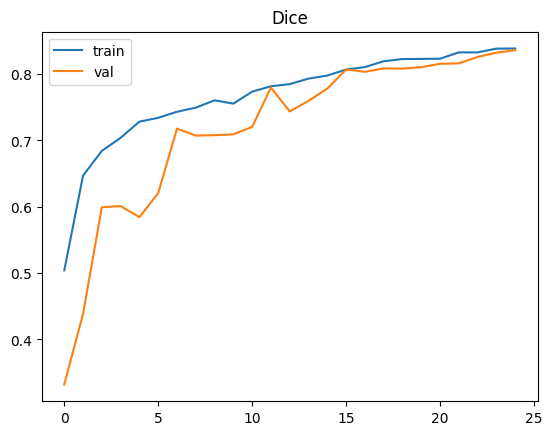

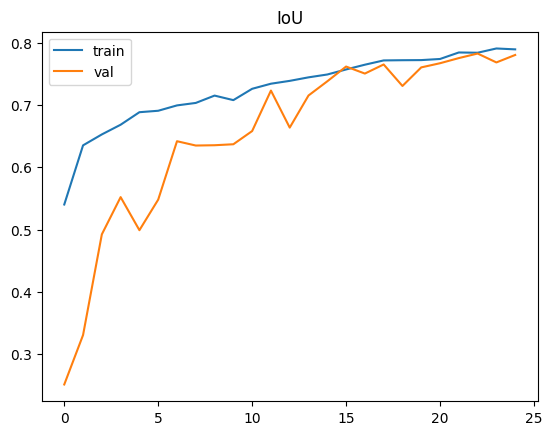

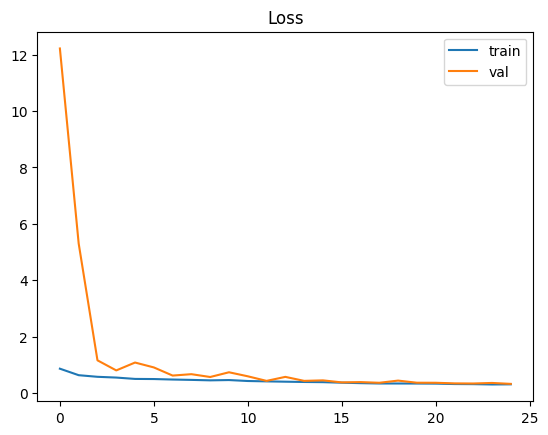

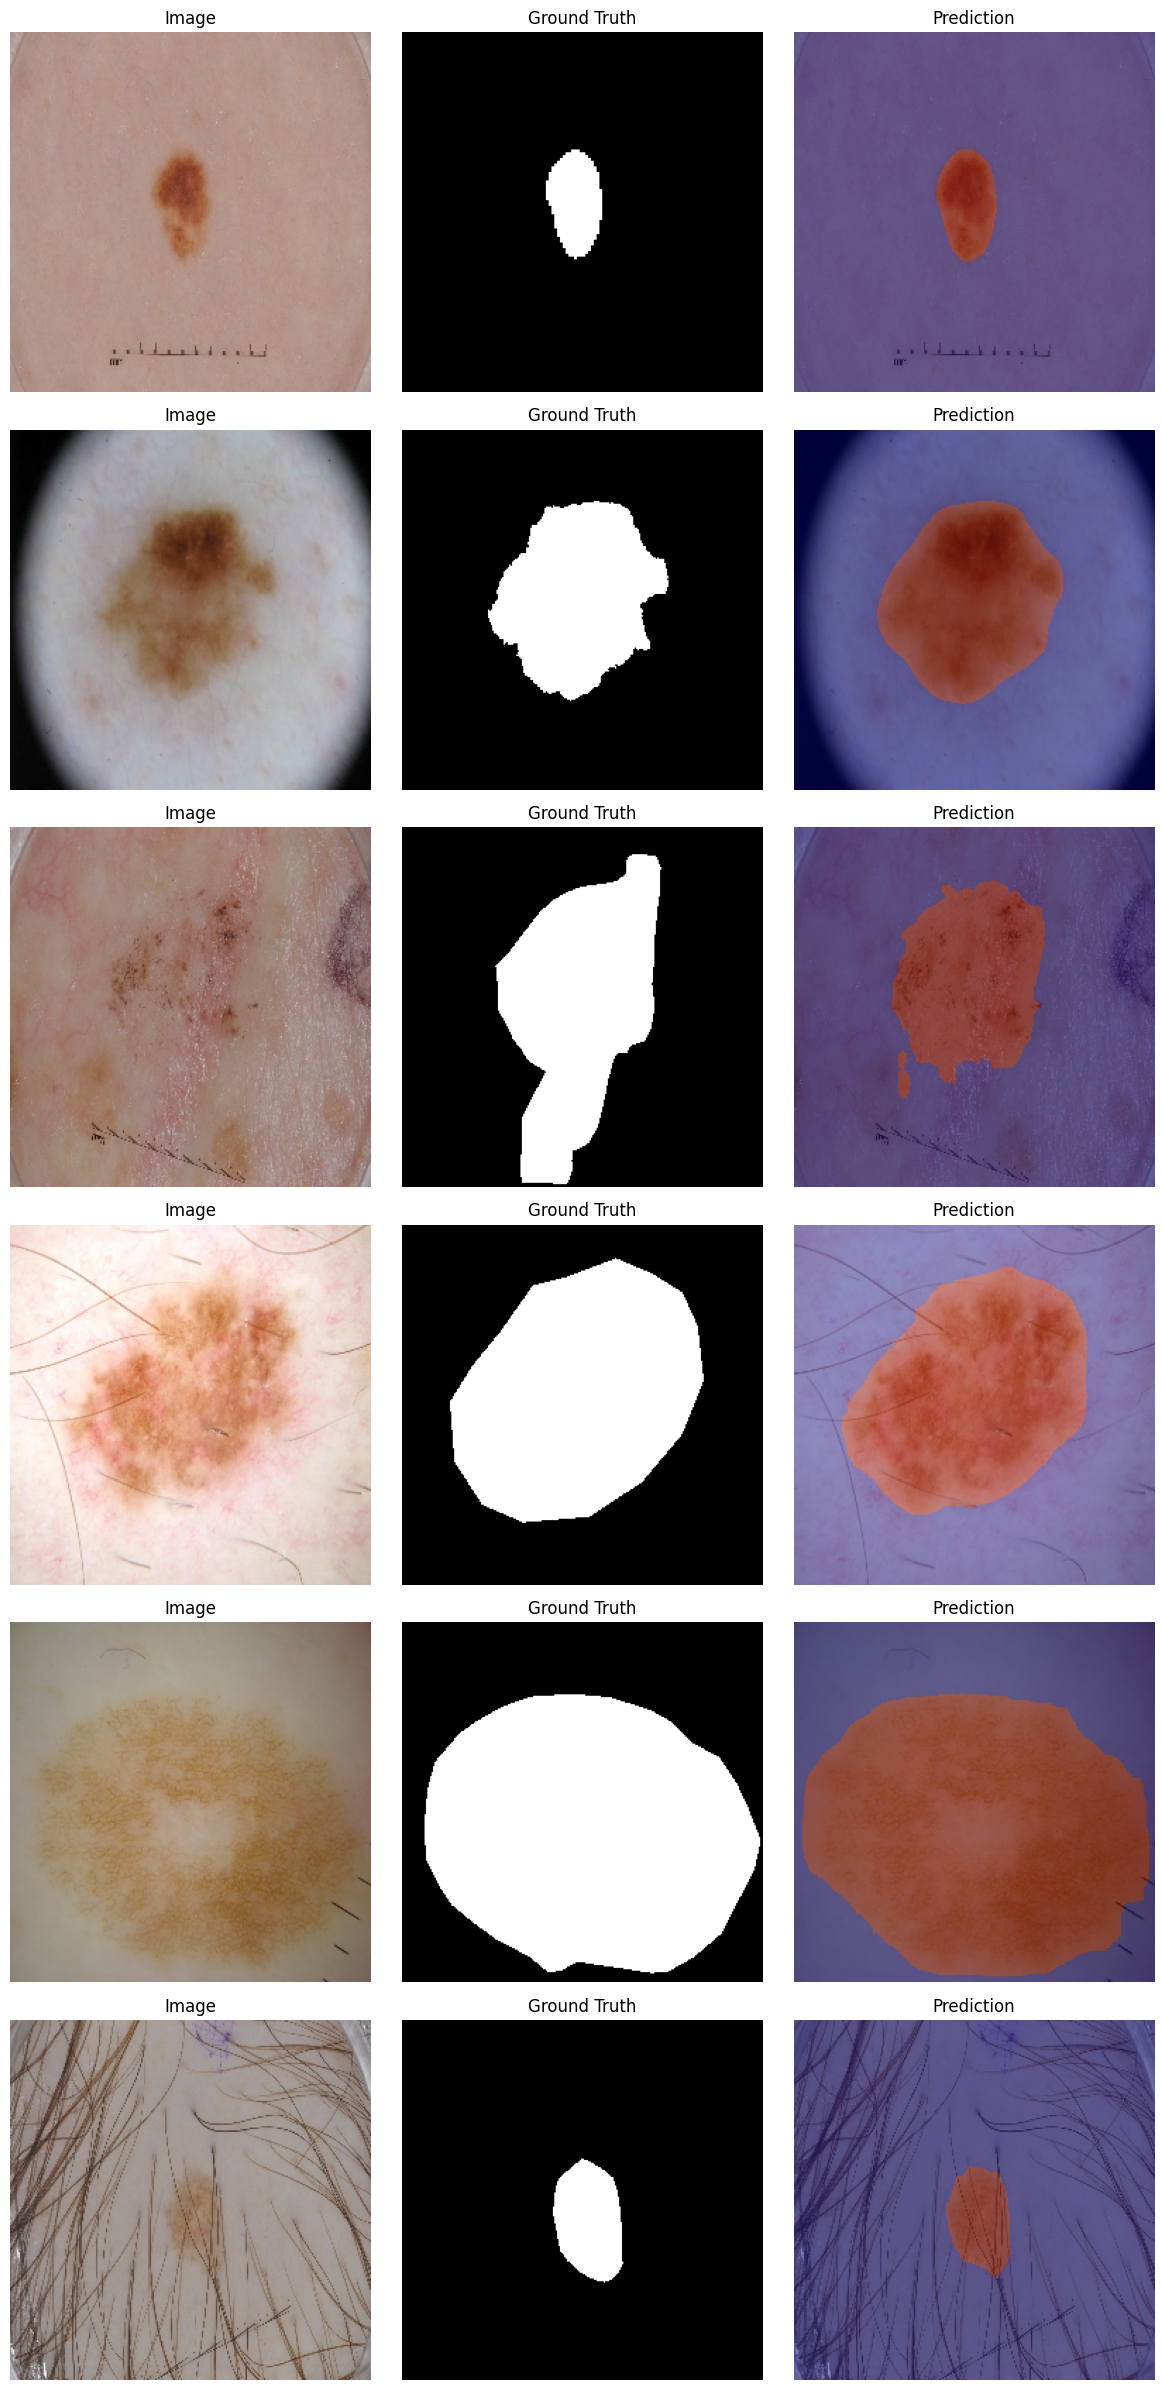

Test Dice: 0.8526 | Test IoU: 0.7981


In [ ]:
# curves
plt.figure(); plt.plot(history.history["dice_coef"]); plt.plot(history.history["val_dice_coef"]);
plt.title("Dice"); plt.legend(["train","val"]); plt.show()

plt.figure(); plt.plot(history.history["iou_coef"]); plt.plot(history.history["val_iou_coef"]);
plt.title("IoU"); plt.legend(["train","val"]); plt.show()

plt.figure(); plt.plot(history.history["loss"]); plt.plot(history.history["val_loss"]);
plt.title("Loss"); plt.legend(["train","val"]); plt.show()

# qualitative grid
def show_preds(ds, n=6):
    imgs, msks = next(iter(ds))
    preds = (model.predict(imgs, verbose=0) > THRESH).astype(np.uint8)
    rows, cols = n, 3
    plt.figure(figsize=(12, 4*rows))
    for i in range(rows):
        plt.subplot(rows, cols, i*cols+1); plt.imshow(imgs[i]); plt.axis("off"); plt.title("Image")
        plt.subplot(rows, cols, i*cols+2); plt.imshow(msks[i].numpy().squeeze(), cmap="gray"); plt.axis("off"); plt.title("Ground Truth")
        plt.subplot(rows, cols, i*cols+3); plt.imshow(imgs[i]); plt.imshow(preds[i].squeeze(), cmap="jet", alpha=0.45); plt.axis("off"); plt.title("Prediction")
    plt.tight_layout(); plt.show()

show_preds(test_ds, n=6)

# quantitative test
def eval_ds(ds):
    d_list, i_list = [], []
    for imgs, msks in ds:
        preds = model.predict(imgs, verbose=0)
        d_list.append(dice_coef(msks, preds).numpy())
        i_list.append(iou_coef(msks, preds).numpy())
    return float(np.mean(d_list)), float(np.mean(i_list))

test_dice, test_iou = eval_ds(test_ds)
print(f"Test Dice: {test_dice:.4f} | Test IoU: {test_iou:.4f}")


In [ ]:
model.save("/content/unet_isic2018_final.h5")
print("Saved to /content/unet_isic2018_final.h5")


Saved to /content/unet_isic2018_final.h5


In [ ]:
# Save model
model.save("/content/unet_isic2018_final.h5")

# Save curves
import matplotlib.pyplot as plt
def save_curve(h, key, out):
    plt.figure(); plt.plot(h.history[key]); plt.plot(h.history[f"val_{key}"])
    plt.title(key); plt.legend(["train","val"]); plt.savefig(out, dpi=150); plt.close()

save_curve(history, "loss",      "/content/curve_loss.png")
save_curve(history, "dice_coef", "/content/curve_dice.png")
save_curve(history, "iou_coef",  "/content/curve_iou.png")

# Save prediction grid (same as you displayed)
imgs, msks = next(iter(test_ds))
preds = (model.predict(imgs, verbose=0) > 0.5).astype("uint8")
import numpy as np
rows, cols = 6, 3
plt.figure(figsize=(12, 4*rows))
for i in range(rows):
    plt.subplot(rows, cols, i*cols+1); plt.imshow(imgs[i]); plt.axis("off"); plt.title("Image")
    plt.subplot(rows, cols, i*cols+2); plt.imshow(msks[i].numpy().squeeze(), cmap="gray"); plt.axis("off"); plt.title("Ground Truth")
    plt.subplot(rows, cols, i*cols+3); plt.imshow(imgs[i]); plt.imshow(preds[i].squeeze(), cmap="jet", alpha=0.45); plt.axis("off"); plt.title("Prediction")
plt.tight_layout(); plt.savefig("/content/pred_grid.png", dpi=150); plt.close()


In [ ]:
print(f"Test Dice: {test_dice:.4f} | Test IoU: {test_iou:.4f}")

Test Dice: 0.8526 | Test IoU: 0.7981
